# Model evaluation: email-only heuristic vs Mistral

## 1. Objective, evaluation boundary, and limitations

This notebook compares two frozen sets of structured predictions for 50 synthetic insurance submissions: an **email-only heuristic baseline** and a **Mistral extractor** that receives the email and its attachments.

Evaluation reads only `data/ground_truth.csv`, `outputs/rule_predictions.jsonl`, and `outputs/mistral_predictions.jsonl`. It does not call either extractor or the Mistral API, change predictions, use labels during prediction generation, relabel records, or write derived files. This preserves the separation between extraction and evaluation.

The benchmark is small, synthetic, and used during development. It supports model comparison and failure analysis, but it is not an unbiased estimate of production performance.


## 2. Metric definitions

| Metric | Applies to | Definition |
|---|---|---|
| Text exact accuracy | Company name; industry | Exact after case-folding and collapsing repeated whitespace |
| Revenue exact accuracy | Revenue | Exact whole-number equality; decimals are rejected rather than truncated |
| Exact-set accuracy | Countries; requested coverages | Order-independent equality after text normalisation |
| Micro precision / recall / F1 | Countries; requested coverages | Globally aggregated item-level TP, FP, and FN counts |
| Coverage | All extracted fields | Non-null scalar or non-empty list prediction |
| Full-record accuracy | Submission | All five extracted fields are exactly correct |

A missing prediction is incorrect. An explicitly predicted empty list may match an expected empty list, but remains uncovered. Rates are shown with raw counts.


## 3. Imports, paths, labels, and display configuration

Project-root discovery checks the current directory and its parents, so the notebook works from either the repository root or `notebooks/`.


In [1]:
from __future__ import annotations

import json
from collections.abc import Callable
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    """Find the repository root from the current directory or a parent."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "data" / "ground_truth.csv"
        ).is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Launch Jupyter from the repository "
        "root or its notebooks/ directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
GROUND_TRUTH_PATH = PROJECT_ROOT / "data" / "ground_truth.csv"
RULE_PREDICTIONS_PATH = PROJECT_ROOT / "outputs" / "rule_predictions.jsonl"
MISTRAL_PREDICTIONS_PATH = PROJECT_ROOT / "outputs" / "mistral_predictions.jsonl"

LIST_FIELDS: tuple[str, ...] = ("countries", "requested_coverages")
ALL_FIELDS: tuple[str, ...] = (
    "company_name",
    "revenue",
    "industry",
    "countries",
    "requested_coverages",
)
COMPARISON_FIELDS: tuple[str, ...] = (*ALL_FIELDS, "full_record")
REQUIRED_COLUMNS: set[str] = {"submission_id", *ALL_FIELDS}
FIELD_LABELS: dict[str, str] = {
    "company_name": "Company name",
    "revenue": "Revenue",
    "industry": "Industry",
    "countries": "Countries",
    "requested_coverages": "Requested coverages",
    "full_record": "Full record",
}
MODEL_LABELS: dict[str, str] = {
    "rule": "Email-only heuristic",
    "mistral": "Mistral",
}
MODEL_COLORS: dict[str, str] = {"rule": "#4477AA", "mistral": "#EE7733"}
FIELD_ORDER = {field: position for position, field in enumerate(COMPARISON_FIELDS)}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)


## 4. Pandas input loading and artifact-integrity checks

The checks below cover only the frozen-artifact boundary needed for a reliable comparison: files exist and are non-empty; Pandas can parse them; required columns and rows exist; IDs are present, unique, and exactly matched; and required ground-truth values and JSON list arrays are valid. Prediction field types are guaranteed by the extraction schema and are not revalidated here.


In [2]:
def require_input_file(file_path: Path) -> None:
    """Reject a missing or byte-empty required input."""
    if not file_path.is_file():
        raise FileNotFoundError(f"Required input is missing: {file_path}")
    if file_path.stat().st_size == 0:
        raise ValueError(f"Required input is empty: {file_path}")


def parse_json_array(value: str, *, field: str) -> list[object]:
    """Parse one ground-truth JSON array."""
    try:
        parsed = json.loads(value)
    except (json.JSONDecodeError, TypeError) as error:
        raise ValueError(f"Ground-truth {field} must contain JSON arrays") from error
    if not isinstance(parsed, list):
        raise TypeError(f"Ground-truth {field} must contain JSON arrays")
    return parsed


def validate_artifact(table: pd.DataFrame, *, name: str) -> None:
    """Check the tabular shape and submission IDs needed for comparison."""
    if table.empty:
        raise ValueError(f"{name} is empty")
    missing_columns = REQUIRED_COLUMNS - set(table.columns)
    if missing_columns:
        raise ValueError(f"{name} is missing columns: {sorted(missing_columns)}")
    submission_ids = table["submission_id"]
    missing_ids = submission_ids.isna() | submission_ids.astype("string").str.strip().eq("")
    if bool(missing_ids.any()):
        raise ValueError(f"{name} contains a missing submission ID")
    if bool(submission_ids.duplicated().any()):
        duplicates = sorted(submission_ids.loc[submission_ids.duplicated(False)].astype(str).unique())
        raise ValueError(f"{name} contains duplicate submission IDs: {duplicates}")


def validate_prediction_ids(
    truth: pd.DataFrame, predictions: pd.DataFrame, *, model_name: str
) -> None:
    """Require one prediction for every ground-truth ID and no others."""
    expected_ids = set(truth["submission_id"])
    predicted_ids = set(predictions["submission_id"])
    missing_ids = sorted(expected_ids - predicted_ids)
    unexpected_ids = sorted(predicted_ids - expected_ids)
    if missing_ids or unexpected_ids:
        raise ValueError(
            f"{model_name} prediction ID mismatch. Missing: {missing_ids}; "
            f"unexpected: {unexpected_ids}"
        )


for input_path in (GROUND_TRUTH_PATH, RULE_PREDICTIONS_PATH, MISTRAL_PREDICTIONS_PATH):
    require_input_file(input_path)

ground_truth = pd.read_csv(
    GROUND_TRUTH_PATH,
    converters={
        "countries": lambda value: parse_json_array(value, field="countries"),
        "requested_coverages": lambda value: parse_json_array(
            value, field="requested_coverages"
        ),
    },
)
rule_predictions = pd.read_json(RULE_PREDICTIONS_PATH, lines=True, dtype=False)
mistral_predictions = pd.read_json(MISTRAL_PREDICTIONS_PATH, lines=True, dtype=False)

validate_artifact(ground_truth, name="Ground truth")
validate_artifact(rule_predictions, name="Email-only heuristic predictions")
validate_artifact(mistral_predictions, name="Mistral predictions")

missing_truth = ground_truth.loc[:, list(ALL_FIELDS)].isna()
if bool(missing_truth.any(axis=None)):
    missing_fields = sorted(missing_truth.columns[missing_truth.any()].tolist())
    raise ValueError(f"Ground truth contains missing required values: {missing_fields}")

validate_prediction_ids(ground_truth, rule_predictions, model_name="Email-only heuristic")
validate_prediction_ids(ground_truth, mistral_predictions, model_name="Mistral")

validation_summary = pd.DataFrame(
    [
        {
            "Input": label,
            "File": str(path.relative_to(PROJECT_ROOT)),
            "Records": len(table),
            "Unique IDs": table["submission_id"].nunique(),
            "Artifact checks": "Passed",
        }
        for label, path, table in (
            ("Ground truth", GROUND_TRUTH_PATH, ground_truth),
            ("Email-only heuristic", RULE_PREDICTIONS_PATH, rule_predictions),
            ("Mistral", MISTRAL_PREDICTIONS_PATH, mistral_predictions),
        )
    ]
)
display(validation_summary.style.hide(axis="index"))


Input,File,Records,Unique IDs,Artifact checks
Ground truth,data/ground_truth.csv,50,50,Passed
Email-only heuristic,outputs/rule_predictions.jsonl,50,50,Passed
Mistral,outputs/mistral_predictions.jsonl,50,50,Passed


## 5. Normalisation and field comparison

Field behaviour is explicit in `COMPARATORS`. These functions implement metric semantics, not a second prediction-schema validator.


In [3]:
def is_missing(value: object) -> bool:
    """Detect a scalar missing value without treating a list as a scalar."""
    if isinstance(value, list):
        return False
    return bool(pd.isna(value))


def normalize_text(value: object) -> str | None:
    """Trim, collapse whitespace, and case-fold text."""
    if is_missing(value):
        return None
    return " ".join(str(value).split()).casefold()


def normalize_revenue(value: object) -> int | None:
    """Normalise a whole-number revenue without truncating decimals."""
    if is_missing(value):
        return None
    number = float(value)
    if not number.is_integer():
        raise ValueError(f"Revenue must be a whole number, got {value!r}")
    return int(number)


def normalize_list(value: object) -> set[str]:
    """Normalise a supported list field to an order-independent text set."""
    normalised = (normalize_text(item) for item in value)
    return {item for item in normalised if item is not None}


def text_matches(expected: object, predicted: object) -> bool:
    """Compare a required text label with a nullable prediction."""
    return not is_missing(predicted) and normalize_text(expected) == normalize_text(predicted)


def revenue_matches(expected: object, predicted: object) -> bool:
    """Compare whole-number revenue exactly."""
    return not is_missing(predicted) and normalize_revenue(expected) == normalize_revenue(predicted)


def list_matches(expected: object, predicted: object) -> bool:
    """Compare list fields as normalised, order-independent sets."""
    return not is_missing(predicted) and normalize_list(expected) == normalize_list(predicted)


def prediction_is_present(value: object) -> bool:
    """Define coverage as a non-null scalar or non-empty list."""
    if is_missing(value):
        return False
    return bool(value) if isinstance(value, list) else True


Comparator = Callable[[object, object], bool]
COMPARATORS: dict[str, Comparator] = {
    "company_name": text_matches,
    "revenue": revenue_matches,
    "industry": text_matches,
    "countries": list_matches,
    "requested_coverages": list_matches,
}


## 6. Tidy record/field-level evaluation table

Ground truth and each prediction artifact are melted to long form and merged one-to-one on submission and field. The resulting `details` table—one row per model, submission, and field—is the shared source for all subsequent analysis.


In [4]:
expected_long = ground_truth.melt(
    id_vars="submission_id",
    value_vars=list(ALL_FIELDS),
    var_name="field",
    value_name="expected",
)


def build_model_details(predictions: pd.DataFrame, *, model: str) -> pd.DataFrame:
    """Reshape and compare one frozen prediction artifact."""
    predicted_long = predictions.melt(
        id_vars="submission_id",
        value_vars=list(ALL_FIELDS),
        var_name="field",
        value_name="predicted",
    )
    model_details = expected_long.merge(
        predicted_long,
        on=["submission_id", "field"],
        how="inner",
        validate="one_to_one",
    )
    model_details.insert(0, "model", model)
    model_details["present"] = model_details["predicted"].map(prediction_is_present)
    model_details["correct"] = [
        COMPARATORS[field](expected, predicted)
        for field, expected, predicted in model_details[
            ["field", "expected", "predicted"]
        ].itertuples(index=False, name=None)
    ]
    return model_details


details = pd.concat(
    [
        build_model_details(rule_predictions, model="rule"),
        build_model_details(mistral_predictions, model="mistral"),
    ],
    ignore_index=True,
)
details["_field_order"] = details["field"].map(FIELD_ORDER)
details = (
    details.sort_values(["model", "submission_id", "_field_order"])
    .drop(columns="_field_order")
    .reset_index(drop=True)
)

display(details.head(10).style.hide(axis="index"))


model,submission_id,field,expected,predicted,present,correct
mistral,E001,company_name,Everstead Pharma Ltd,Everstead Pharma Ltd,True,True
mistral,E001,revenue,14608818,14608818.000000,True,True
mistral,E001,industry,Manufacturing,Manufacturing,True,True
mistral,E001,countries,"['Sweden', 'Canada', 'Singapore']","['Sweden', 'Canada', 'Singapore']",True,True
mistral,E001,requested_coverages,"['Kidnap & Ransom', 'Property']","['Kidnap & Ransom', 'Property']",True,True
mistral,E002,company_name,Crestline Textiles Ltd,Crestline Textiles Ltd,True,True
mistral,E002,revenue,38122777,38122777.000000,True,True
mistral,E002,industry,Technology,Technology,True,True
mistral,E002,countries,"['Spain', 'Norway', 'Belgium']","['Spain', 'Norway', 'Belgium']",True,True
mistral,E002,requested_coverages,"['General Liability', 'Property']","['General Liability', 'Property']",True,True


## 7. Headline accuracy and coverage summary

Field accuracy and coverage are grouped directly from the tidy table. Full-record correctness is a grouped `all()` over the five field results for each model and submission. Numeric calculation tables remain numeric; formatting is applied only to the display copy.


In [5]:
field_summary = (
    details.groupby(["model", "field"], observed=True, sort=False)
    .agg(
        correct=("correct", "sum"),
        total=("correct", "size"),
        present=("present", "sum"),
        coverage=("present", "mean"),
    )
    .reset_index()
)
field_summary["accuracy"] = field_summary["correct"] / field_summary["total"]

full_record_details = (
    details.groupby(["model", "submission_id"], observed=True, sort=False)["correct"]
    .all()
    .rename("full_record_correct")
    .reset_index()
)
full_record_summary = (
    full_record_details.groupby("model", observed=True, sort=False)
    .agg(correct=("full_record_correct", "sum"), total=("full_record_correct", "size"))
    .reset_index()
)
full_record_summary["accuracy"] = (
    full_record_summary["correct"] / full_record_summary["total"]
)

scorecard_numeric = pd.concat(
    [
        field_summary[
            ["model", "field", "correct", "total", "accuracy", "present", "coverage"]
        ],
        full_record_summary.assign(
            field="full_record", present=pd.NA, coverage=float("nan")
        )[
            ["model", "field", "correct", "total", "accuracy", "present", "coverage"]
        ],
    ],
    ignore_index=True,
)
scorecard_numeric["present"] = scorecard_numeric["present"].astype("Int64")
scorecard_numeric["_field_order"] = scorecard_numeric["field"].map(FIELD_ORDER)
scorecard_numeric = (
    scorecard_numeric.sort_values(["_field_order", "model"])
    .drop(columns="_field_order")
    .reset_index(drop=True)
)

scorecard_rows: list[dict[str, object]] = []
for field in COMPARISON_FIELDS:
    row: dict[str, object] = {"Field": FIELD_LABELS[field]}
    for model, label in MODEL_LABELS.items():
        metric = scorecard_numeric.loc[
            (scorecard_numeric["model"] == model)
            & (scorecard_numeric["field"] == field)
        ].iloc[0]
        row[f"{label} accuracy"] = (
            f"{metric['accuracy']:.0%} ({int(metric['correct'])}/{int(metric['total'])})"
        )
        row[f"{label} coverage"] = (
            "—"
            if pd.isna(metric["coverage"])
            else f"{metric['coverage']:.0%} ({int(metric['present'])}/{int(metric['total'])})"
        )
    rule_accuracy = scorecard_numeric.loc[
        (scorecard_numeric["model"] == "rule")
        & (scorecard_numeric["field"] == field),
        "accuracy",
    ].iloc[0]
    mistral_accuracy = scorecard_numeric.loc[
        (scorecard_numeric["model"] == "mistral")
        & (scorecard_numeric["field"] == field),
        "accuracy",
    ].iloc[0]
    row["Difference"] = f"{(mistral_accuracy - rule_accuracy) * 100:+.0f} pp"
    scorecard_rows.append(row)

scorecard_display = pd.DataFrame(scorecard_rows)
display(scorecard_display.style.hide(axis="index"))


Field,Email-only heuristic accuracy,Email-only heuristic coverage,Mistral accuracy,Mistral coverage,Difference
Company name,90% (45/50),100% (50/50),96% (48/50),98% (49/50),+6 pp
Revenue,98% (49/50),100% (50/50),92% (46/50),98% (49/50),-6 pp
Industry,70% (35/50),74% (37/50),94% (47/50),96% (48/50),+24 pp
Countries,72% (36/50),74% (37/50),90% (45/50),98% (49/50),+18 pp
Requested coverages,80% (40/50),80% (40/50),98% (49/50),100% (50/50),+18 pp
Full record,64% (32/50),—,76% (38/50),—,+12 pp


Mistral improves company name, industry, countries, requested coverages, and full-record accuracy. The largest gain is industry, where attachment context closes many baseline gaps. Revenue is the exception: its six-point regression shows that locating plausible numbers is easier than applying the intended entity and period precedence consistently. The current 76% full-record result supports an assisted workflow, not straight-through automation.


## 8. List precision, recall, F1, and TP/FP/FN

Normalised item sets and their intersections and differences are calculated once. The same missing and unexpected sets feed both globally aggregated list metrics and later error diagnostics.


In [6]:
list_details = details.loc[details["field"].isin(LIST_FIELDS)].copy()
list_details["expected_items"] = list_details["expected"].map(normalize_list)
list_details["predicted_items"] = list_details["predicted"].map(
    lambda value: set() if is_missing(value) else normalize_list(value)
)
list_details["true_positive_items"] = [
    expected & predicted
    for expected, predicted in list_details[
        ["expected_items", "predicted_items"]
    ].itertuples(index=False, name=None)
]
list_details["missing_items"] = [
    sorted(expected - predicted)
    for expected, predicted in list_details[
        ["expected_items", "predicted_items"]
    ].itertuples(index=False, name=None)
]
list_details["unexpected_items"] = [
    sorted(predicted - expected)
    for expected, predicted in list_details[
        ["expected_items", "predicted_items"]
    ].itertuples(index=False, name=None)
]
list_details["true_positive"] = list_details["true_positive_items"].map(len)
list_details["false_positive"] = list_details["unexpected_items"].map(len)
list_details["false_negative"] = list_details["missing_items"].map(len)

list_metric_summary = (
    list_details.groupby(["model", "field"], observed=True, sort=False)[
        ["true_positive", "false_positive", "false_negative"]
    ]
    .sum()
    .reset_index()
)


def zero_safe_ratio(numerator: int, denominator: int) -> float:
    """Return zero when a list-metric denominator is zero."""
    return numerator / denominator if denominator else 0.0


list_metric_summary["precision"] = [
    zero_safe_ratio(tp, tp + fp)
    for tp, fp in list_metric_summary[
        ["true_positive", "false_positive"]
    ].itertuples(index=False, name=None)
]
list_metric_summary["recall"] = [
    zero_safe_ratio(tp, tp + fn)
    for tp, fn in list_metric_summary[
        ["true_positive", "false_negative"]
    ].itertuples(index=False, name=None)
]
list_metric_summary["f1"] = [
    zero_safe_ratio(2 * precision * recall, precision + recall)
    for precision, recall in list_metric_summary[
        ["precision", "recall"]
    ].itertuples(index=False, name=None)
]

list_metric_display = list_metric_summary.copy()
list_metric_display["Model"] = list_metric_display["model"].map(MODEL_LABELS)
list_metric_display["Field"] = list_metric_display["field"].map(FIELD_LABELS)
for metric in ("precision", "recall", "f1"):
    list_metric_display[metric.title()] = list_metric_display[metric].map("{:.1%}".format)
list_metric_display["TP / FP / FN"] = list_metric_display.apply(
    lambda row: (
        f"{int(row['true_positive'])} / {int(row['false_positive'])} / "
        f"{int(row['false_negative'])}"
    ),
    axis=1,
)
display(
    list_metric_display[
        ["Model", "Field", "Precision", "Recall", "F1", "TP / FP / FN"]
    ].style.hide(axis="index")
)


Model,Field,Precision,Recall,F1,TP / FP / FN
Mistral,Countries,89.9%,96.7%,93.2%,89 / 10 / 3
Mistral,Requested coverages,99.0%,99.0%,99.0%,103 / 1 / 1
Email-only heuristic,Countries,97.1%,71.7%,82.5%,66 / 2 / 26
Email-only heuristic,Requested coverages,100.0%,77.9%,87.6%,81 / 0 / 23


The email-only baseline is precise but recall-limited for list fields, consistent with information being absent from many email bodies. Mistral recovers most missing items, but its country false positives lower precision; operationally, unsupported countries can trigger unnecessary referrals or sanctions checks.


## 9. Paired model comparison

`pivot()` places rule and Mistral correctness side by side for every submission and field. The four outcomes therefore compare the models on exactly the same examples.


In [7]:
full_record_long = full_record_details.rename(
    columns={"full_record_correct": "correct"}
).assign(field="full_record")
paired_source = pd.concat(
    [
        details[["model", "submission_id", "field", "correct"]],
        full_record_long[["model", "submission_id", "field", "correct"]],
    ],
    ignore_index=True,
)
paired_results = (
    paired_source.pivot(
        index=["submission_id", "field"], columns="model", values="correct"
    )
    .reset_index()
    .rename_axis(columns=None)
)
if bool(paired_results[["rule", "mistral"]].isna().any(axis=None)):
    raise ValueError("Paired comparison contains an unmatched model result")

OUTCOME_ORDER = ["Both correct", "Rule only", "Mistral only", "Both incorrect"]
PAIRED_OUTCOMES = {
    (True, True): "Both correct",
    (True, False): "Rule only",
    (False, True): "Mistral only",
    (False, False): "Both incorrect",
}
paired_results["outcome"] = [
    PAIRED_OUTCOMES[(bool(rule), bool(mistral))]
    for rule, mistral in paired_results[["rule", "mistral"]].itertuples(
        index=False, name=None
    )
]

paired_outcome_pivot = (
    paired_results.groupby(["field", "outcome"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=COMPARISON_FIELDS, columns=OUTCOME_ORDER, fill_value=0)
)
paired_outcome_summary = (
    paired_outcome_pivot.rename_axis(index="field", columns=None).reset_index()
)
paired_outcome_display = paired_outcome_summary.copy()
paired_outcome_display["Field"] = paired_outcome_display["field"].map(FIELD_LABELS)
display(
    paired_outcome_display[["Field", *OUTCOME_ORDER]].style.hide(axis="index")
)

full_record_outcomes = []
full_record_pairs = paired_results.loc[paired_results["field"] == "full_record"]
for outcome in OUTCOME_ORDER:
    submission_ids = full_record_pairs.loc[
        full_record_pairs["outcome"] == outcome, "submission_id"
    ].sort_values().tolist()
    full_record_outcomes.append(
        {
            "Paired full-record outcome": outcome,
            "Count": len(submission_ids),
            "Submission IDs": ", ".join(submission_ids) if submission_ids else "—",
        }
    )
full_record_outcomes = pd.DataFrame(full_record_outcomes)
display(full_record_outcomes.style.hide(axis="index"))

model_disagreements = paired_results.loc[
    paired_results["rule"] != paired_results["mistral"]
].copy()
model_disagreements["better_model"] = model_disagreements["rule"].map(
    {True: "rule", False: "mistral"}
)
disagreement_summary = (
    model_disagreements.groupby(["field", "better_model"], observed=True)[
        "submission_id"
    ]
    .agg(count="size", submission_ids=lambda values: ", ".join(sorted(values)))
    .reset_index()
)
disagreement_display = disagreement_summary.copy()
disagreement_display["Field"] = disagreement_display["field"].map(FIELD_LABELS)
disagreement_display["Better on this field"] = disagreement_display[
    "better_model"
].map(MODEL_LABELS)
disagreement_display["Count"] = disagreement_display["count"]
disagreement_display["Submission IDs"] = disagreement_display["submission_ids"]
display(
    disagreement_display[
        ["Field", "Better on this field", "Count", "Submission IDs"]
    ].style.hide(axis="index")
)


Field,Both correct,Rule only,Mistral only,Both incorrect
Company name,44,1,4,1
Revenue,46,3,0,1
Industry,34,1,13,2
Countries,35,1,10,4
Requested coverages,39,1,10,0
Full record,31,1,7,11


Paired full-record outcome,Count,Submission IDs
Both correct,31,"E001, E002, E003, E004, E005, E006, E009, E010, E011, E012, E013, E015, E016, E017, E018, E019, E020, E021, E022, E023, E025, E026, E027, E028, E029, E030, E031, E032, E033, E034, E035"
Rule only,1,E008
Mistral only,7,"E037, E038, E041, E043, E045, E048, E049"
Both incorrect,11,"E007, E014, E024, E036, E039, E040, E042, E044, E046, E047, E050"


Field,Better on this field,Count,Submission IDs
Company name,Mistral,4,"E046, E048, E049, E050"
Company name,Email-only heuristic,1,E008
Countries,Mistral,10,"E038, E039, E040, E041, E042, E045, E047, E048, E049, E050"
Countries,Email-only heuristic,1,E008
Full record,Mistral,7,"E037, E038, E041, E043, E045, E048, E049"
Full record,Email-only heuristic,1,E008
Industry,Mistral,13,"E036, E038, E039, E041, E042, E043, E044, E045, E046, E047, E048, E049, E050"
Industry,Email-only heuristic,1,E008
Requested coverages,Mistral,10,"E037, E039, E040, E043, E044, E046, E047, E048, E049, E050"
Requested coverages,Email-only heuristic,1,E042


At full-record level, Mistral uniquely succeeds on seven submissions and the rule baseline uniquely succeeds on one. Eleven are wrong under both approaches, identifying the most valuable records for error investigation. These paired counts describe this benchmark only; they do not establish a statistically generalisable win rate.


## 10. Charts

The first chart consumes the numeric scorecard directly through Seaborn. The second uses the paired-outcome pivot as a stacked horizontal bar chart.


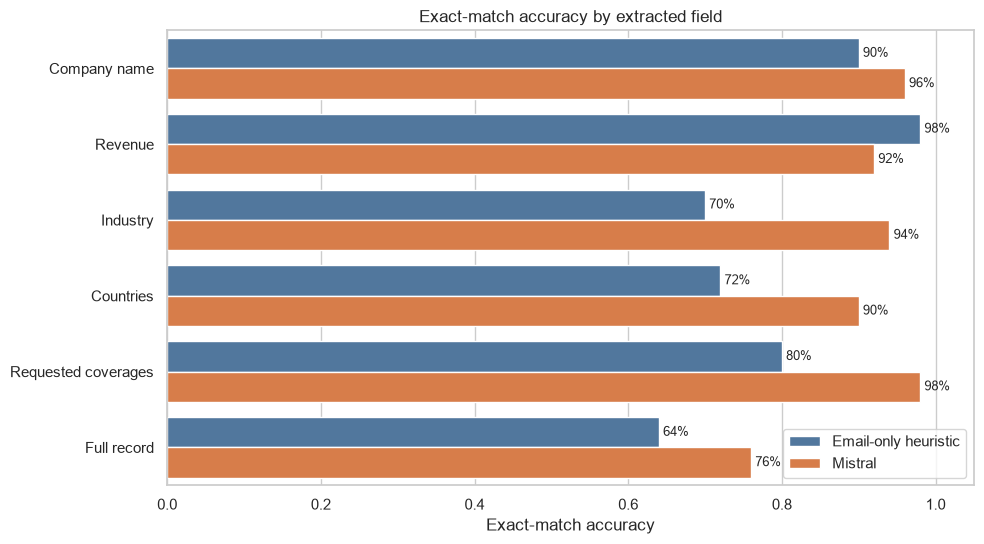

In [8]:
accuracy_chart_data = scorecard_numeric.copy()
accuracy_chart_data["Field"] = accuracy_chart_data["field"].map(FIELD_LABELS)
accuracy_chart_data["Model"] = accuracy_chart_data["model"].map(MODEL_LABELS)

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.barplot(
    data=accuracy_chart_data,
    x="accuracy",
    y="Field",
    hue="Model",
    hue_order=list(MODEL_LABELS.values()),
    palette={MODEL_LABELS[key]: value for key, value in MODEL_COLORS.items()},
    errorbar=None,
    ax=ax,
)
ax.set_xlabel("Exact-match accuracy")
ax.set_ylabel("")
ax.set_title("Exact-match accuracy by extracted field")
ax.set_xlim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_width():.0%}" for bar in container], padding=3, fontsize=9)
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


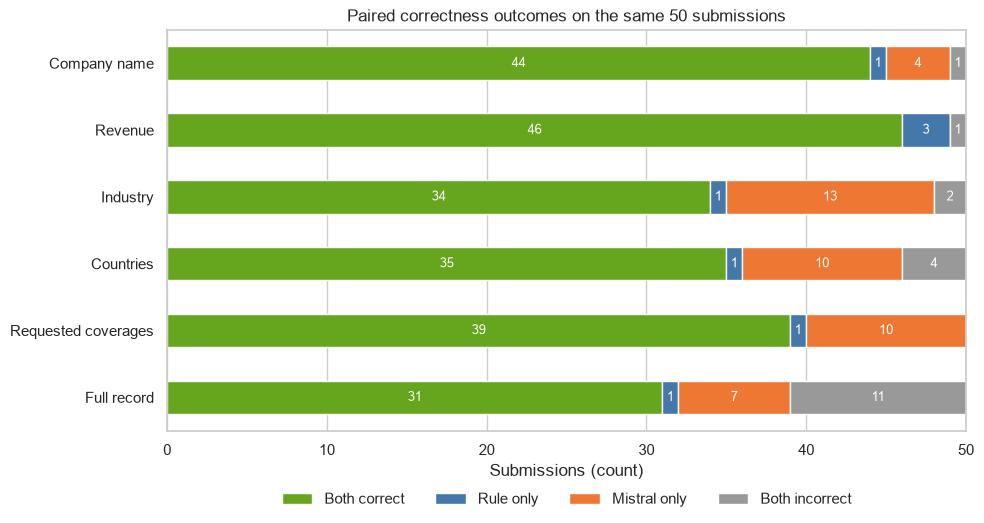

In [9]:
outcome_colors = {
    "Both correct": "#66A61E",
    "Rule only": MODEL_COLORS["rule"],
    "Mistral only": MODEL_COLORS["mistral"],
    "Both incorrect": "#999999",
}
paired_chart_data = paired_outcome_pivot.copy()
paired_chart_data.index = paired_chart_data.index.map(FIELD_LABELS)
ax = paired_chart_data.plot.barh(
    stacked=True,
    figsize=(10, 5.8),
    color=[outcome_colors[outcome] for outcome in OUTCOME_ORDER],
)
for container in ax.containers:
    labels = [str(int(bar.get_width())) if bar.get_width() else "" for bar in container]
    ax.bar_label(container, labels=labels, label_type="center", color="white", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Submissions (count)")
ax.set_ylabel("")
ax.set_title("Paired correctness outcomes on the same 50 submissions")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()


Attachment-aware extraction materially improves context-heavy fields, while the accuracy chart makes the revenue trade-off visible. Full-record accuracy is lower than every field-level rate because any one mismatch makes the complete submission incorrect.


## 11. Error analysis and selected examples

The main error table is the incorrect subset of `details`. `missing_prediction` means a null scalar or null/empty list; other mismatches are `incorrect_value`. List diagnostics reuse the item differences calculated for the list metrics.


In [10]:
list_diagnostics = list_details[
    ["model", "submission_id", "field", "missing_items", "unexpected_items"]
]
errors = details.loc[~details["correct"]].merge(
    list_diagnostics,
    on=["model", "submission_id", "field"],
    how="left",
    validate="one_to_one",
)
errors["missing_items"] = errors["missing_items"].map(
    lambda value: value if isinstance(value, list) else []
)
errors["unexpected_items"] = errors["unexpected_items"].map(
    lambda value: value if isinstance(value, list) else []
)
errors["failure_type"] = errors["present"].map(
    {True: "incorrect_value", False: "missing_prediction"}
)
errors = errors.sort_values(["model", "field", "submission_id"]).reset_index(drop=True)

error_summary = (
    errors.groupby(["model", "field", "failure_type"], observed=True)
    .size()
    .rename("Error count")
    .reset_index()
)
error_summary_display = error_summary.copy()
error_summary_display["Model"] = error_summary_display["model"].map(MODEL_LABELS)
error_summary_display["Field"] = error_summary_display["field"].map(FIELD_LABELS)
error_summary_display["Failure type"] = error_summary_display[
    "failure_type"
].str.replace("_", " ")
display(
    error_summary_display[
        ["Model", "Field", "Failure type", "Error count"]
    ].style.hide(axis="index")
)


Model,Field,Failure type,Error count
Mistral,Company name,incorrect value,1
Mistral,Company name,missing prediction,1
Mistral,Countries,incorrect value,4
Mistral,Countries,missing prediction,1
Mistral,Industry,incorrect value,1
Mistral,Industry,missing prediction,2
Mistral,Requested coverages,incorrect value,1
Mistral,Revenue,incorrect value,3
Mistral,Revenue,missing prediction,1
Email-only heuristic,Company name,incorrect value,5


In [11]:
def format_value(value: object) -> str:
    """Format values compactly without hiding list contents."""
    if is_missing(value):
        return "—"
    if isinstance(value, list):
        return json.dumps(value, ensure_ascii=False)
    return str(value)


def present_errors(table: pd.DataFrame) -> pd.DataFrame:
    """Create a readable error drill-down table."""
    presented = table.copy()
    presented["Model"] = presented["model"].map(MODEL_LABELS)
    presented["Submission ID"] = presented["submission_id"]
    presented["Field"] = presented["field"].map(FIELD_LABELS)
    presented["Expected"] = presented["expected"].map(format_value)
    presented["Predicted"] = presented["predicted"].map(format_value)
    presented["Failure type"] = presented["failure_type"].str.replace("_", " ")
    presented["Expected items missing"] = presented["missing_items"].map(format_value)
    presented["Unexpected items added"] = presented["unexpected_items"].map(format_value)
    return presented[
        [
            "Model",
            "Submission ID",
            "Field",
            "Expected",
            "Predicted",
            "Failure type",
            "Expected items missing",
            "Unexpected items added",
        ]
    ]


display(Markdown("### Company-name and revenue errors"))
scalar_drilldown = errors.loc[errors["field"].isin(["company_name", "revenue"])]
display(present_errors(scalar_drilldown).style.hide(axis="index"))

display(Markdown("### Unsupported or omitted countries"))
country_drilldown = errors.loc[
    (errors["field"] == "countries")
    & (errors["missing_items"].map(bool) | errors["unexpected_items"].map(bool))
]
display(present_errors(country_drilldown).style.hide(axis="index"))

display(Markdown("### Model disagreements"))
display(
    disagreement_display[
        ["Field", "Better on this field", "Count", "Submission IDs"]
    ].style.hide(axis="index")
)

display(Markdown("### Baseline omissions: attachment-only evidence candidates"))
attachment_candidates = errors.loc[
    (errors["model"] == "rule")
    & (errors["failure_type"] == "missing_prediction")
    & errors["field"].isin(["industry", "countries", "requested_coverages"])
]
attachment_summary = (
    attachment_candidates.groupby("field", observed=True)["submission_id"]
    .agg(count="size", submission_ids=lambda values: ", ".join(sorted(values)))
    .reset_index()
)
attachment_summary_display = attachment_summary.copy()
attachment_summary_display["Field"] = attachment_summary_display["field"].map(FIELD_LABELS)
attachment_summary_display["Count"] = attachment_summary_display["count"]
attachment_summary_display["Submission IDs"] = attachment_summary_display["submission_ids"]
display(
    attachment_summary_display[["Field", "Count", "Submission IDs"]].style.hide(
        axis="index"
    )
)
display(Markdown("Selected examples (up to three per field)"))
attachment_examples = (
    attachment_candidates.sort_values(["field", "submission_id"])
    .groupby("field", observed=True)
    .head(3)
)
display(present_errors(attachment_examples).style.hide(axis="index"))


### Company-name and revenue errors

Model,Submission ID,Field,Expected,Predicted,Failure type,Expected items missing,Unexpected items added
Mistral,E008,Company name,Redwood Manufacturing Ltd,—,missing prediction,[],[]
Mistral,E047,Company name,Maplecrest Industries Systems Ltd,Maplecrest Industries Ltd,incorrect value,[],[]
Mistral,E007,Revenue,546984,488379.0,incorrect value,[],[]
Mistral,E008,Revenue,16614618,—,missing prediction,[],[]
Mistral,E039,Revenue,7237085,4848846.0,incorrect value,[],[]
Mistral,E050,Revenue,2008613,2510767.0,incorrect value,[],[]
Email-only heuristic,E046,Company name,Westhaven Insights Ltd,Westhaven Insights Analytics Ltd,incorrect value,[],[]
Email-only heuristic,E047,Company name,Maplecrest Industries Systems Ltd,Maplecrest Industries Ltd,incorrect value,[],[]
Email-only heuristic,E048,Company name,Silverline Ventures Ltd,Silverline Ventures UK,incorrect value,[],[]
Email-only heuristic,E049,Company name,Harbourview Services Europe Ltd,Harbourview Services Ltd,incorrect value,[],[]


### Unsupported or omitted countries

Model,Submission ID,Field,Expected,Predicted,Failure type,Expected items missing,Unexpected items added
Mistral,E008,Countries,"[""France"", ""United Arab Emirates"", ""Singapore""]",—,missing prediction,"[""france"", ""singapore"", ""united arab emirates""]",[]
Mistral,E024,Countries,"[""Ireland""]","[""Ireland"", ""France"", ""Canada""]",incorrect value,[],"[""canada"", ""france""]"
Mistral,E036,Countries,"[""Norway""]","[""United Kingdom"", ""Europe"", ""North America"", ""Norway""]",incorrect value,[],"[""europe"", ""north america"", ""united kingdom""]"
Mistral,E044,Countries,"[""United States""]","[""United Kingdom"", ""Europe"", ""North America"", ""United States"", ""Rest of world""]",incorrect value,[],"[""europe"", ""north america"", ""rest of world"", ""united kingdom""]"
Mistral,E046,Countries,"[""Denmark"", ""United States"", ""Singapore""]","[""Denmark"", ""United Kingdom"", ""United States"", ""Singapore""]",incorrect value,[],"[""united kingdom""]"
Email-only heuristic,E024,Countries,"[""Ireland""]","[""Ireland"", ""France"", ""Canada""]",incorrect value,[],"[""canada"", ""france""]"
Email-only heuristic,E036,Countries,"[""Norway""]",—,missing prediction,"[""norway""]",[]
Email-only heuristic,E038,Countries,"[""Sweden"", ""Ireland"", ""Italy""]",—,missing prediction,"[""ireland"", ""italy"", ""sweden""]",[]
Email-only heuristic,E039,Countries,"[""Belgium"", ""United States""]",—,missing prediction,"[""belgium"", ""united states""]",[]
Email-only heuristic,E040,Countries,"[""Norway""]",—,missing prediction,"[""norway""]",[]


### Model disagreements

Field,Better on this field,Count,Submission IDs
Company name,Mistral,4,"E046, E048, E049, E050"
Company name,Email-only heuristic,1,E008
Countries,Mistral,10,"E038, E039, E040, E041, E042, E045, E047, E048, E049, E050"
Countries,Email-only heuristic,1,E008
Full record,Mistral,7,"E037, E038, E041, E043, E045, E048, E049"
Full record,Email-only heuristic,1,E008
Industry,Mistral,13,"E036, E038, E039, E041, E042, E043, E044, E045, E046, E047, E048, E049, E050"
Industry,Email-only heuristic,1,E008
Requested coverages,Mistral,10,"E037, E039, E040, E043, E044, E046, E047, E048, E049, E050"
Requested coverages,Email-only heuristic,1,E042


### Baseline omissions: attachment-only evidence candidates

Field,Count,Submission IDs
Countries,13,"E036, E038, E039, E040, E041, E042, E044, E045, E046, E047, E048, E049, E050"
Industry,13,"E036, E038, E039, E041, E042, E043, E044, E045, E046, E047, E048, E049, E050"
Requested coverages,10,"E037, E039, E040, E043, E044, E046, E047, E048, E049, E050"


Selected examples (up to three per field)

Model,Submission ID,Field,Expected,Predicted,Failure type,Expected items missing,Unexpected items added
Email-only heuristic,E036,Countries,"[""Norway""]",—,missing prediction,"[""norway""]",[]
Email-only heuristic,E038,Countries,"[""Sweden"", ""Ireland"", ""Italy""]",—,missing prediction,"[""ireland"", ""italy"", ""sweden""]",[]
Email-only heuristic,E039,Countries,"[""Belgium"", ""United States""]",—,missing prediction,"[""belgium"", ""united states""]",[]
Email-only heuristic,E036,Industry,Life Sciences,—,missing prediction,[],[]
Email-only heuristic,E038,Industry,Hospitality,—,missing prediction,[],[]
Email-only heuristic,E039,Industry,Education,—,missing prediction,[],[]
Email-only heuristic,E037,Requested coverages,"[""Technology E&O"", ""Cyber"", ""General Liability""]",—,missing prediction,"[""cyber"", ""general liability"", ""technology e&o""]",[]
Email-only heuristic,E039,Requested coverages,"[""Directors & Officers"", ""Management Liability"", ""Technology E&O""]",—,missing prediction,"[""directors & officers"", ""management liability"", ""technology e&o""]",[]
Email-only heuristic,E040,Requested coverages,"[""Directors & Officers"", ""Media Liability"", ""Kidnap & Ransom""]",—,missing prediction,"[""directors & officers"", ""kidnap & ransom"", ""media liability""]",[]


These are diagnostic categories, not manual relabelling. Revenue and company-name mismatches flag precedence or entity-resolution questions; country additions expose false positives; and baseline omissions are candidates for attachment-only evidence rather than proof that every missing value appears there. Headline scores remain unchanged against the supplied ground truth.

Suspected label-quality issues require independent domain adjudication. Any future sensitivity analysis should be labelled separately and must not replace the raw benchmark.


## 12. Conclusions and next steps

### Measured benchmark result

On these 50 supplied synthetic records, Mistral improves full-record exact accuracy from **64% (32/50)** to **76% (38/50)**. Its strongest improvement is industry, followed by countries and requested coverages, consistent with useful information being concentrated in attachments. Revenue moves in the opposite direction, from **98% (49/50)** to **92% (46/50)**. The paired full-record result is 31 both correct, 7 Mistral only, 1 rule only, and 11 both incorrect.

### Operational interpretation

Neither result supports straight-through automation. At 76% full-record accuracy, about one in four benchmark submissions contains at least one wrong field. A safer use is assisted intake with field-level evidence and review routing.

### Limitations

- The dataset contains only 50 synthetic submissions and was used during iteration.
- Exact match is sensitive to possible label ambiguity that has not been independently adjudicated.
- Mistral results come from one run using a `latest` alias; temperature zero does not guarantee repeatability.
- Markdown inputs do not test OCR, PDFs, spreadsheets, images, email-thread reconstruction, latency, cost, privacy controls, or drift.
- Field errors are weighted equally despite different business consequences.

### Recommended next steps

1. Adjudicate ambiguous labels and freeze annotation guidance.
2. Evaluate larger held-out data stratified by complexity and source format.
3. Return source documents and evidence spans, then add confidence or deterministic review flags.
4. Agree field-level precision and recall requirements and route high-risk predictions to people.
5. Pin model and prompt versions, record run metadata, repeat runs, and measure latency and cost.
6. Add canonical post-validation and malformed-document and prompt-injection tests.
